In [34]:
%cd /Data/gfi/users/rogui7909/code/predict_rain_norway

/felles_gfi/felles_gfi_users/rogui7909/code/predict_rain_norway


In [35]:
print('Running imports...')
import os
import os
os.environ["MKL_THREADING_LAYER"] = "GNU"

import wandb
import numpy as np
import torch # long
import xarray as xr

from coral_pytorch.losses import corn_loss
from coral_pytorch.dataset import corn_label_from_logits
from models.model import CNN_Model, CNN_Model_ChannelAttention, CNN_Model_SpatialAttention
import pandas as pd
from torch import nn
from lightning.pytorch import loggers, seed_everything
from models.lightning import LitCNN_regression, AttributableTrainer
# from models.losses import get_loss
import matplotlib
from models.data import get_input_data_from_wandb_logger,get_input_data_from_wandb_logger_three_types
# from models.model import get_model
import matplotlib.pyplot as plt
import cmocean.cm as cmo
from lightning.pytorch.callbacks.early_stopping import EarlyStopping
plt.style.use('robin')
# matplotlib.use('tkagg')
torch.set_float32_matmul_precision('medium')
seed_everything(42, workers=True)
import seaborn as sns 
import argparse
from tqdm.notebook import tqdm
import cartopy.crs as ccrs

Seed set to 42


Running imports...


In [36]:
wandb_logger = loggers.WandbLogger(project="Predict-rain-WNorway_backtoclassif", 
                                    save_dir="/Data/gfi/users/rogui7909/wanbd_logs/",
                                    dir="/Data/gfi/users/rogui7909/wanbd_logs/wandb", )

wandb_logger.experiment # Initialize wandb

train_loader, val_loader, test_loader, ds_test = get_input_data_from_wandb_logger_three_types(wandb_logger, lon_lim=(-128, 53))

callbacks=[EarlyStopping(monitor="val/loss", mode="min")]
trainer = AttributableTrainer(limit_train_batches=100, 
                                max_epochs=wandb_logger.experiment.config['num_epochs'], 
                                logger=wandb_logger, 
                                log_every_n_steps=1, default_root_dir="/Data/gfi/users/rogui7909/lightning_checkpoint/",
                                callbacks=callbacks, deterministic=True,
                                accelerator="gpu", devices=1,)

wandb_logger.experiment.config['num_classes'] = wandb_logger.experiment.config['num_timesteps_predicted']*3
wandb_logger.experiment.config['num_channels'] = len(wandb_logger.experiment.config['input_variables'])

/Scientific_software/software/Anaconda3/2024.06-1/lib/python3.12/site-packages/pydantic/main.py:308: UserWarning: Pydantic serializer warnings:
  Expected `list[str]` but got `tuple` - serialized value may not be as expected
  Expected `list[str]` but got `tuple` - serialized value may not be as expected
  return self.__pydantic_serializer__.to_python(
/Scientific_software/software/Anaconda3/2024.06-1/lib/python3.12/site-packages/pydantic/main.py:308: UserWarning: Pydantic serializer warnings:
  Expected `list[str]` but got `tuple` - serialized value may not be as expected
  Expected `list[str]` but got `tuple` - serialized value may not be as expected
  return self.__pydantic_serializer__.to_python(


/Data/gfi/users/rogui7909/virtual_envs/postdoc/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Data ready:
    Image size: 2048 (64x32)
    Input data: u850, v850
    4 Predicted timesteps for future rainfall
    90th percentile predicted


In [37]:
class CNN_Model_2(nn.Module):
    def __init__(self, 
                 input_channels, 
                 image_size, 
                 num_timesteps,
                 number_conv_layers=4,
                 size_conv_kernel=3,
                 out_channels_conv1=12, 
                 out_channel_factor_increase_per_layer = 2,
                 ):
        super(CNN_Model_2, self).__init__()
        
        # CNN layers to extract spatial features
        # self.sigmoid = sigmoid
        # self.softmax = softmax
        self.num_timesteps = num_timesteps
        self.classes_per_timestep = 3
        self.num_classes = self.num_timesteps*(self.classes_per_timestep-1)
        self.number_conv_layers = number_conv_layers
        self.conv_layer1 = nn.Sequential(
                                     nn.Conv2d(input_channels, 
                                     out_channels_conv1, 
                                     kernel_size=size_conv_kernel, 
                                     stride=1, padding=(size_conv_kernel-1)//2),
                            nn.MaxPool2d(kernel_size=2, stride=2),
                            nn.ReLU())
        self.conv_layer2 = nn.Sequential(
                                nn.Conv2d(out_channels_conv1, 
                                          out_channels_conv1*out_channel_factor_increase_per_layer, 
                                          kernel_size=size_conv_kernel, 
                                          stride=1, padding=(size_conv_kernel-1)//2),
                                nn.MaxPool2d(kernel_size=2, stride=2),
                                nn.ReLU())
        self.conv_layer3 = nn.Sequential(
                                nn.Conv2d(out_channels_conv1*out_channel_factor_increase_per_layer, 
                                          out_channels_conv1*out_channel_factor_increase_per_layer**2, 
                                          kernel_size=size_conv_kernel, 
                                          stride=1, padding=(size_conv_kernel-1)//2),
                                nn.MaxPool2d(kernel_size=2, stride=2),
                                nn.ReLU())
        self.conv_layer4 = nn.Sequential(
                                nn.Conv2d(out_channels_conv1*out_channel_factor_increase_per_layer**2, 
                                          out_channels_conv1*out_channel_factor_increase_per_layer**3, 
                                          kernel_size=size_conv_kernel, 
                                          stride=1, padding=(size_conv_kernel-1)//2),
                                nn.MaxPool2d(kernel_size=2, stride=2),
                                nn.ReLU())
        self.conv_layer5 = nn.Sequential(
                                nn.Conv2d(out_channels_conv1*out_channel_factor_increase_per_layer**3, 
                                          out_channels_conv1*out_channel_factor_increase_per_layer**4, 
                                          kernel_size=size_conv_kernel, 
                                          stride=1, padding=(size_conv_kernel-1)//2),
                                nn.MaxPool2d(kernel_size=2, stride=2),
                                nn.ReLU())
        self.conv_layer6 = nn.Sequential(
                                nn.Conv2d(out_channels_conv1*out_channel_factor_increase_per_layer**4, 
                                            out_channels_conv1*out_channel_factor_increase_per_layer**5, 
                                            kernel_size=size_conv_kernel, 
                                            stride=1, padding=1),
                                nn.MaxPool2d(kernel_size=(1,2), stride=2),
                                nn.ReLU())
        
        if number_conv_layers == 1:
            self.cnn = nn.Sequential(self.conv_layer1)
        elif number_conv_layers == 2:
            self.cnn = nn.Sequential(self.conv_layer1, self.conv_layer2)
        elif number_conv_layers == 3:
            self.cnn = nn.Sequential(self.conv_layer1, self.conv_layer2, self.conv_layer3)
        elif number_conv_layers == 4:
            self.cnn = nn.Sequential(self.conv_layer1, self.conv_layer2, self.conv_layer3, self.conv_layer4)
        elif number_conv_layers == 5:
            self.cnn = nn.Sequential(self.conv_layer1, self.conv_layer2, self.conv_layer3, self.conv_layer4, self.conv_layer5)
        elif number_conv_layers == 6:
            self.cnn = nn.Sequential(self.conv_layer1, self.conv_layer2, self.conv_layer3, self.conv_layer4, self.conv_layer5, self.conv_layer6)
        
        max_pools = 4**(number_conv_layers)
        self.output_cnn_channels  = out_channels_conv1*out_channel_factor_increase_per_layer**(number_conv_layers-1)
        if self.number_conv_layers == 0:
            self.linear_size = image_size 
        else:
            self.linear_size = image_size * self.output_cnn_channels // max_pools 
        if self.number_conv_layers == 6:
            self.linear_size = self.linear_size*2
        if self.number_conv_layers == 0:
            self.linear_size = image_size*2 
        self.fc1 = nn.Linear(self.linear_size, 512)
        self.fc2 = nn.Linear(512, self.num_classes)
    
    def forward(self, x):
        # x shape: (batch_size, seq_length, channels, height, width)
        # Apply CNN to extract spatial features
        batch_size,  channels, height, width = x.size()
        if self.number_conv_layers>0:
            cnn_out = self.cnn(x)
        else:
            cnn_out = x
        cnn_out = cnn_out.view(batch_size, -1)  # Shape: (batch_size, seq_length, features)
        output = self.fc1(cnn_out)  # Shape: (batch_size, output_size)
        output = self.fc2(output)
        output = output.view(-1, self.num_timesteps, self.classes_per_timestep-1)
        output = torch.sigmoid(output) 
        X1 = output[:,:,0]
        X2 = output[:,:,1]
        P_norain = X1 
        P_rain = (1-X1)*(1-X2)
        P_extreme = (1-X1)*X2
        output = torch.stack([P_norain, P_rain, P_extreme], dim=2)
        return output.view(-1, self.num_timesteps*self.classes_per_timestep)
        # print(output.shape)
        
NN = CNN_Model_2(input_channels = wandb_logger.experiment.config['num_channels'], 
               image_size=wandb_logger.experiment.config['image_size'], 
               num_timesteps=wandb_logger.experiment.config['num_timesteps_predicted'],
               number_conv_layers=wandb_logger.experiment.config['num_conv_layer'],
               size_conv_kernel=wandb_logger.experiment.config['size_conv_kernel'],
               out_channels_conv1=wandb_logger.experiment.config['conv1_kernel_number'], 
               out_channel_factor_increase_per_layer = wandb_logger.experiment.config['factor_increase_kernels_per_conv_layer'],)
 
NN(train_loader.dataset[0][0][:20]).shape


torch.Size([20, 12])

In [38]:
import torch
import torch.nn as nn

class PatchEmbedding(nn.Module):
    def __init__(self, in_channels, patch_size, emb_dim):
        super().__init__()
        self.patch_size = patch_size
        self.emb_dim = emb_dim
        self.proj = nn.Conv2d(in_channels, emb_dim, kernel_size=patch_size, stride=patch_size)

        self.pos_embed = None  # We'll create this dynamically

    def forward(self, x):
        # x: (B, C, H, W)
        x = self.proj(x)  # (B, emb_dim, H/P, W/P)
        B, D, Hp, Wp = x.shape
        x = x.flatten(2).transpose(1, 2)  # (B, N, D) where N = Hp * Wp

        # Create positional embeddings dynamically
        if self.pos_embed is None or self.pos_embed.shape[1] != x.shape[1]:
            self.pos_embed = nn.Parameter(torch.randn(1, x.shape[1], self.emb_dim, device=x.device))

        x = x + self.pos_embed
        return x  # (B, N, D)

class ViT_Model(nn.Module):
    def __init__(self, 
                 input_channels, 
                 num_timesteps,
                 patch_size=4,
                 emb_dim=128,
                 num_layers=6,
                 num_heads=8,
                 mlp_dim=256,
                 dropout=0.1):
        super().__init__()
        self.num_timesteps = num_timesteps
        self.classes_per_timestep = 3
        self.num_classes = self.num_timesteps * (self.classes_per_timestep - 1)

        self.patch_embed = PatchEmbedding(input_channels, patch_size, emb_dim)

        encoder_layer = nn.TransformerEncoderLayer(d_model=emb_dim, nhead=num_heads,
                                                   dim_feedforward=mlp_dim, dropout=dropout, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.norm = nn.LayerNorm(emb_dim)

        self.mlp_head = nn.Sequential(
            nn.Linear(emb_dim, 512),
            nn.ReLU(),
            nn.Linear(512, self.num_classes)
        )

    def forward(self, x):
        # x: (B, C, H, W)
        x = self.patch_embed(x)      # (B, N, D)
        x = self.transformer(x)      # (B, N, D)
        x = self.norm(x.mean(dim=1)) # (B, D), mean pooling
        x = self.mlp_head(x)         # (B, num_classes)
        
        x = x.view(-1, self.num_timesteps, self.classes_per_timestep - 1)
        x = torch.sigmoid(x)

        X1 = x[:, :, 0]
        X2 = x[:, :, 1]
        P_norain = X1
        P_rain = (1 - X1) * (1 - X2)
        P_extreme = (1 - X1) * X2
        out = torch.stack([P_norain, P_rain, P_extreme], dim=2)

        return out.view(-1, self.num_timesteps * self.classes_per_timestep)


NN = ViT_Model(input_channels = wandb_logger.experiment.config['num_channels'], 
               num_timesteps=wandb_logger.experiment.config['num_timesteps_predicted'],
               )
 
NN(train_loader.dataset[0][0][:20]).shape


torch.Size([20, 12])

In [39]:
NN = CNN_Model_2(input_channels = wandb_logger.experiment.config['num_channels'], 
               image_size=wandb_logger.experiment.config['image_size'], 
               num_timesteps=wandb_logger.experiment.config['num_timesteps_predicted'],
               number_conv_layers=wandb_logger.experiment.config['num_conv_layer'],
               size_conv_kernel=wandb_logger.experiment.config['size_conv_kernel'],
               out_channels_conv1=wandb_logger.experiment.config['conv1_kernel_number'], 
               out_channel_factor_increase_per_layer = wandb_logger.experiment.config['factor_increase_kernels_per_conv_layer'],)
 
# NN = ViT_Model(input_channels = wandb_logger.experiment.config['num_channels'], 
#                num_timesteps=wandb_logger.experiment.config['num_timesteps_predicted'],
#                )
class MultiCrossEntropyLoss(nn.Module):
    def __init__(self, timesteps):
        super(MultiCrossEntropyLoss, self).__init__()
        self.nll = torch.nn.NLLLoss(weight = torch.Tensor([1,1,9]))
        self.timesteps = timesteps
        
    def forward(self, pred, target):
        """
        Computes the loss for the given prediction.
        """
        loss = []
        pred = pred.view(-1, self.timesteps, 3)
        proba = torch.softmax(pred, dim=2)
        for k,timestep in enumerate(range(self.timesteps)):
            res = self.nll(torch.log(proba[:,timestep]), target[:,timestep])
            loss.append(res)#*(k+1)/10)
        loss = torch.mean(torch.stack(loss))
        return loss
    

loss = MultiCrossEntropyLoss(timesteps = wandb_logger.experiment.config['num_timesteps_predicted'])


model = LitCNN_regression(NN, 
                          learning_rate=wandb_logger.experiment.config['learning_rate'], 
                          lr_scheduler =wandb_logger.experiment.config['lr_scheduler'],
                          loss_fn = loss)


In [40]:
trainer.fit(model, train_loader, val_loader)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name    | Type                  | Params | Mode 
----------------------------------------------------------
0 | model   | CNN_Model_2           | 234 K  | train
1 | loss_fn | MultiCrossEntropyLoss | 0      | train
----------------------------------------------------------
234 K     Trainable params
0         Non-trainable params
234 K     Total params
0.937     Total estimated model params size (MB)
30        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/Data/gfi/users/rogui7909/virtual_envs/postdoc/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
/Data/gfi/users/rogui7909/virtual_envs/postdoc/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

In [41]:
model.eval()
with torch.no_grad():
    trainer.test(model, dataloaders=val_loader)
wandb.finish()

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/Data/gfi/users/rogui7909/virtual_envs/postdoc/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/loss         │    0.9229749441146851     │
└───────────────────────────┴───────────────────────────┘

epoch,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▄▄▄▅▅▅▆▆▆▆▆▆▇█████
test/loss,▁
train/loss,█▆▆▆▆█▅▆▆▆▅▅▅▄▃▂▃▃▂▂▃▂▃▂▃▃▁▃▃▃▄▂▃▂▃▂▂▁▂▂
trainer/global_step,▁▁▁▂▂▂▂▂▂▂▃▃▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▇▇▇▇███
val/loss,█▇▆▆▆▅▄▄▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,55
test/loss,0.92297
train/loss,0.90143
trainer/global_step,1430
val/loss,0.92297


In [42]:
y_test = torch.stack(model.test_true_values)#.cpu().numpy()
y_scores = torch.stack(model.test_pred).view(-1, wandb_logger.experiment.config['num_timesteps_predicted'], 3)#.cpu().numpy()
preds = torch.argmax(y_scores, dim=2)
targets=xr.DataArray(y_test.cpu().numpy(), dims=['time','timestep'], coords=dict(time=ds_test.time, timestep=np.arange(y_scores.shape[1])))
preds=xr.DataArray(preds.cpu().numpy(), dims=['time','timestep'], coords=dict(time=ds_test.time, timestep=np.arange(y_scores.shape[1])))
results = xr.Dataset(dict(targets=targets, preds=preds))
proba=xr.DataArray(y_scores.cpu().numpy(), dims=['time','timestep','type_rain'], 
                   coords=dict(time=ds_test.time, timestep=np.arange(y_scores.shape[1]), type_rain=['no_rain','moderate_rain','extreme_rain']))
df_=pd.DataFrame(dict(pred=preds.to_series(), targets=targets.to_series()))
df_['pred_time'] = (df_.index.get_level_values(0)+pd.Timedelta(1,'D')*df_.index.get_level_values(1)).values
# model.test_true_values

# pred = torch.stack([corn_label_from_logits(y_scores[:,k]) for k in range(y_scores.shape[1])])

[Text(0, 0, 'D0'), Text(1, 0, 'D+1'), Text(2, 0, 'D+2'), Text(3, 0, 'D+3')]

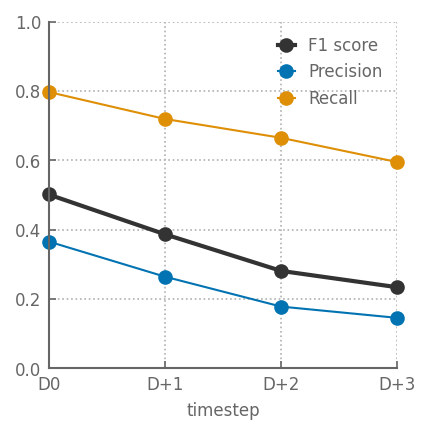

In [43]:
TP = ((preds == targets)&(targets==2)).sum('time')
recall = TP / (targets==2).sum('time')
precision = TP / (preds==2).sum('time')
f1 = 2*(precision*recall)/(precision+recall)



# recall_season.plot(hue='season')
fig, ax = plt.subplots(figsize=(3,3,))
f1.plot(color='.2', lw=2, label='F1 score', marker='o', clip_on=False)
precision.plot(label='Precision', marker='o', clip_on=False)
recall.plot(label='Recall', marker='o', clip_on=False)
plt.legend()
ax.set_ylim(0,1)
ax.grid()
ax.set_xlim(0,3)
ax.set_xticks([0,1,2,3])
ax.set_xticklabels(['D0','D+1','D+2','D+3'])

In [44]:
df_=pd.DataFrame(dict(pred=preds.to_series(), targets=targets.to_series()))
df_['pred_time'] = (df_.index.get_level_values(0)+pd.Timedelta(1,'D')*df_.index.get_level_values(1)).values

times = df_.query("targets==2 & pred==2").groupby('pred_time').count().pred.sort_values()
events_predicted = times.loc[times>3].index
steps = 4
start_times = events_predicted -  pd.Timedelta(steps-1,'D')
print("Number of 4x events:",len(start_times))
num_extremes = df_.targets.loc[df_.targets==2].unstack().count(axis=1)
num_extremes_pred = df_.targets.where((df_.targets==2)&(df_.pred==2)).fillna(0).unstack().sum(axis=1)//2

pred_FP = df_.query("pred==2 & targets<2").groupby('pred_time').count().query("pred==4").index

start_times_FP = pred_FP - pd.Timedelta(steps-1,'D')
# events

Number of 4x events: 114


<xarray.DataArray 'time' (time: 93)> Size: 744B
array(['1995-07-17T00:00:00.000000000', '1995-07-18T00:00:00.000000000',
       '1995-10-04T00:00:00.000000000', '1995-10-14T00:00:00.000000000',
       '1995-10-15T00:00:00.000000000', '1995-11-20T00:00:00.000000000',
       '1995-11-21T00:00:00.000000000', '1996-02-12T00:00:00.000000000',
       '1996-06-05T00:00:00.000000000', '1996-06-09T00:00:00.000000000',
       '1996-10-09T00:00:00.000000000', '1997-01-09T00:00:00.000000000',
       '1997-01-10T00:00:00.000000000', '1997-02-15T00:00:00.000000000',
       '1997-03-23T00:00:00.000000000', '1997-03-24T00:00:00.000000000',
       '1997-03-27T00:00:00.000000000', '1997-03-29T00:00:00.000000000',
       '1997-03-30T00:00:00.000000000', '1997-08-26T00:00:00.000000000',
       '1997-09-12T00:00:00.000000000', '1997-09-13T00:00:00.000000000',
       '1997-09-28T00:00:00.000000000', '1997-12-02T00:00:00.000000000',
       '1997-12-06T00:00:00.000000000', '1998-01-07T00:00:00.000000000',
       '1998-02-06T00:00:00.000000000', '1998-05-05T00:00:00.000000000',
       '1998-08-01T00:00:00.000000000', '1998-08-12T00:00:00.000000000',
       '1998-11-19T00:00:00.000000000', '1999-01-21T00:00:00.000000000',
       '1999-03-13T00:00:00.000000000', '1999-03-26T00:00:00.000000000',
       '1999-05-19T00:00:00.000000000', '1999-05-20T00:00:00.000000000',
       '1999-05-22T00:00:00.000000000', '1999-10-25T00:00:00.000000000',
       '1999-12-03T00:00:00.000000000', '1999-12-04T00:00:00.000000000',
       '1999-12-14T00:00:00.000000000', '1999-12-20T00:00:00.000000000',
       '1999-12-21T00:00:00.000000000', '2000-01-26T00:00:00.000000000',
       '2000-03-03T00:00:00.000000000', '2000-05-25T00:00:00.000000000',
       '2000-05-30T00:00:00.000000000', '2000-06-10T00:00:00.000000000',
       '2000-08-21T00:00:00.000000000', '2000-10-21T00:00:00.000000000',
       '2001-02-08T00:00:00.000000000', '2001-06-17T00:00:00.000000000',
       '2001-08-13T00:00:00.000000000', '2001-09-30T00:00:00.000000000',
       '2001-10-01T00:00:00.000000000', '2001-11-12T00:00:00.000000000',
       '2001-12-29T00:00:00.000000000', '2002-01-30T00:00:00.000000000',
       '2002-03-08T00:00:00.000000000', '2002-06-23T00:00:00.000000000',
       '2002-07-08T00:00:00.000000000', '2002-10-21T00:00:00.000000000',
       '2002-10-23T00:00:00.000000000', '2002-11-03T00:00:00.000000000',
       '2003-01-11T00:00:00.000000000', '2003-06-16T00:00:00.000000000',
       '2003-07-29T00:00:00.000000000', '2003-10-25T00:00:00.000000000',
       '2003-12-07T00:00:00.000000000', '2003-12-10T00:00:00.000000000',
       '2003-12-15T00:00:00.000000000', '2003-12-16T00:00:00.000000000',
       '2003-12-21T00:00:00.000000000', '2004-02-21T00:00:00.000000000',
       '2004-05-15T00:00:00.000000000', '2004-05-16T00:00:00.000000000',
       '2004-06-11T00:00:00.000000000', '2004-08-18T00:00:00.000000000',
       '2004-08-25T00:00:00.000000000', '2004-10-01T00:00:00.000000000',
       '2004-12-01T00:00:00.000000000', '2004-12-11T00:00:00.000000000',
       '2004-12-12T00:00:00.000000000', '2005-03-13T00:00:00.000000000',
       '2005-03-14T00:00:00.000000000', '2005-05-23T00:00:00.000000000',
       '2005-07-16T00:00:00.000000000', '2005-08-26T00:00:00.000000000',
       '2005-09-10T00:00:00.000000000', '2005-09-11T00:00:00.000000000',
       '2005-10-29T00:00:00.000000000', '2005-11-21T00:00:00.000000000',
       '2006-08-25T00:00:00.000000000'], dtype='datetime64[ns]')
Coordinates:
  * time      (time) datetime64[ns] 744B 1995-07-17 1995-07-18 ... 2006-08-25
    timestep  int64 8B 3

In [45]:
with torch.no_grad():
    probas = model.model(train_loader.dataset[0][0])
probas[:,3].argmax()

tensor(128)

In [46]:
# test = train_loader.dataset[0][0][449]
test = train_loader.dataset[0][0][49:50]
test.shape

out11 = model.model.conv_layer1[0](test)
out12 = model.model.conv_layer1[1](out11)
out13 = model.model.conv_layer1[2](out12)

out21 = model.model.conv_layer2[0](out13)
out22 = model.model.conv_layer2[1](out21)
out23 = model.model.conv_layer2[2](out22)

out31 = model.model.conv_layer3[0](out23)
out32 = model.model.conv_layer3[1](out31)
out33 = model.model.conv_layer3[2](out32)

out41 = model.model.conv_layer4[0](out33)
out42 = model.model.conv_layer4[1](out41)
out43 = model.model.conv_layer4[2](out42)


In [141]:
time1 = results.isel(timestep=3).where((results.isel(timestep=3).targets==2)&(results.isel(timestep=3).preds==True), drop=True).time.values
time2 = results.where((results.targets==results.preds), drop=True).time.values
time = [k for k in time1 if k in time2]
len(time)

88

In [142]:
# time = results.isel(timestep=3).where((results.isel(timestep=3).targets==2)&(results.isel(timestep=3).preds==True), drop=True).time
data_in = ds_test.sel(time=time[:10]).inputs
inputs = torch.Tensor(data_in.values)
out11 = model.model.conv_layer1[0](inputs)
out12 = model.model.conv_layer1[1](out11)
out13 = model.model.conv_layer1[2](out12)

out21 = model.model.conv_layer2[0](out13)
out22 = model.model.conv_layer2[1](out21)
out23 = model.model.conv_layer2[2](out22)

out31 = model.model.conv_layer3[0](out23)
out32 = model.model.conv_layer3[1](out31)
out33 = model.model.conv_layer3[2](out32)

out41 = model.model.conv_layer4[0](out33)
out42 = model.model.conv_layer4[1](out41)
out43 = model.model.conv_layer4[2](out42)

mask1 = torch.nn.functional.interpolate(out13, scale_factor=2, mode='bilinear').detach()
mask2 = torch.nn.functional.interpolate(out23, scale_factor=4, mode='bilinear').detach()
mask3 = torch.nn.functional.interpolate(out33, scale_factor=8, mode='bilinear').detach()
mask4 = torch.nn.functional.interpolate(out43, scale_factor=16, mode='bilinear').detach()

mask1 = xr.DataArray(mask1, dims=['time','filter','latitude','longitude'], coords=dict(longitude=data_in.longitude, latitude=data_in.latitude, time=data_in.time))
mask2 = xr.DataArray(mask2, dims=['time','filter','latitude','longitude'], coords=dict(longitude=data_in.longitude, latitude=data_in.latitude, time=data_in.time))
mask3 = xr.DataArray(mask3, dims=['time','filter','latitude','longitude'], coords=dict(longitude=data_in.longitude, latitude=data_in.latitude, time=data_in.time))
mask4 = xr.DataArray(mask4, dims=['time','filter','latitude','longitude'], coords=dict(longitude=data_in.longitude, latitude=data_in.latitude, time=data_in.time))

mask1 = mask1.stack(space=['latitude','longitude']).rank('space',pct=True).unstack()>.9
mask2 = mask2.stack(space=['latitude','longitude']).rank('space',pct=True).unstack()>.9
mask3 = mask3.stack(space=['latitude','longitude']).rank('space',pct=True).unstack()>.9
mask4 = mask4.stack(space=['latitude','longitude']).rank('space',pct=True).unstack()>.9

In [149]:
data_in#.plot(col='time')
# mask2.plot(row='filter', col='time')

<xarray.DataArray 'inputs' (time: 10, var_name: 2, latitude: 32, longitude: 64)> Size: 164kB
array([[[[-6.48869276e-02,  5.23855910e-02,  8.03593993e-02, ...,
           5.87485552e-01,  5.20733237e-01,  3.62285614e-01],
         [ 3.61154735e-01,  5.10347068e-01,  6.38363004e-01, ...,
           1.21966970e+00,  1.36534679e+00,  1.27009010e+00],
         [ 1.18844926e+00,  1.23081589e+00,  1.04859686e+00, ...,
           1.49068701e+00,  1.87925839e+00,  2.30582428e+00],
         ...,
         [-1.08227730e+00, -1.02941668e+00, -9.69970763e-01, ...,
          -1.54625487e+00, -1.72621751e+00, -1.87180424e+00],
         [-7.19412208e-01, -6.98423207e-01, -6.84669018e-01, ...,
          -2.59260297e+00, -2.57588100e+00, -2.56498814e+00],
         [-2.27230147e-01, -2.16048598e-01, -2.02291027e-01, ...,
          -2.06865311e+00, -2.08417654e+00, -2.09243250e+00]],

        [[-7.01438338e-02,  3.42019238e-02,  3.42946947e-01, ...,
           1.78177524e+00,  1.72615850e+00,  1.44555521e+00],
         [-1.02506757e-01, -2.51847029e-01, -1.15752798e-02, ...,
           1.82368755e+00,  2.02976632e+00,  1.82835770e+00],
         [-4.22948480e-01, -4.62196231e-01, -2.40001574e-01, ...,
           1.49713945e+00,  1.80237460e+00,  1.98189092e+00],
...
          -1.97470105e+00, -1.89966094e+00, -1.80461740e+00],
         [ 4.21374828e-01,  3.49528253e-01,  2.79696345e-01, ...,
          -1.76164412e+00, -1.73665988e+00, -1.71409178e+00],
         [ 9.96314108e-01,  9.48926091e-01,  9.02244925e-01, ...,
          -1.77724147e+00, -1.75056577e+00, -1.71852851e+00]],

        [[-5.55409007e-02, -8.60707760e-02, -1.85692579e-01, ...,
           6.45660937e-01,  5.86803436e-01,  6.10238791e-01],
         [-3.66237462e-01, -2.45155931e-01, -3.52386385e-01, ...,
           5.84479868e-01,  5.19526124e-01,  3.94013464e-01],
         [-3.85594189e-01, -1.71354443e-01,  5.97918108e-02, ...,
           4.44082439e-01,  5.22190094e-01,  3.72544318e-01],
         ...,
         [-1.20443678e+00, -1.22125936e+00, -1.23478818e+00, ...,
           8.75436664e-01,  8.91857386e-01,  8.98509920e-01],
         [-1.19255114e+00, -1.21444583e+00, -1.22779167e+00, ...,
           5.03824532e-01,  5.60888946e-01,  6.24638140e-01],
         [-8.25733304e-01, -8.81484866e-01, -9.37809944e-01, ...,
           7.07280397e-01,  7.90696859e-01,  8.71322155e-01]]]],
      dtype=float32)
Coordinates:
  * longitude  (longitude) float64 512B -126.6 -123.8 -120.9 ... 47.81 50.62
  * var_name   (var_name) object 16B 'u850' 'v850'
  * time       (time) datetime64[ns] 80B 1995-07-17 1995-07-18 ... 1996-10-09
  * latitude   (latitude) float64 256B 1.406 4.219 7.031 ... 82.97 85.78 88.59
    mask_id    int64 8B 14

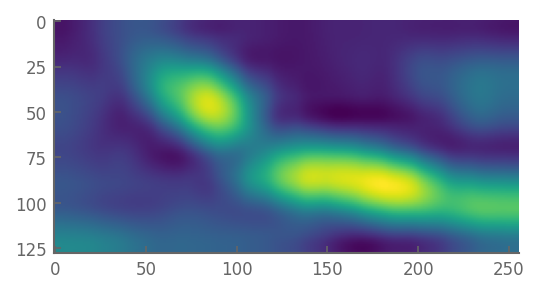

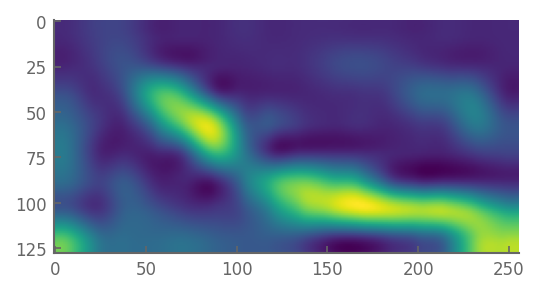

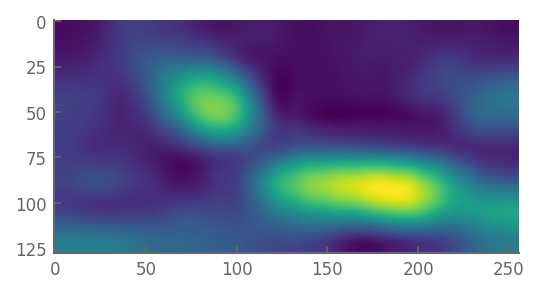

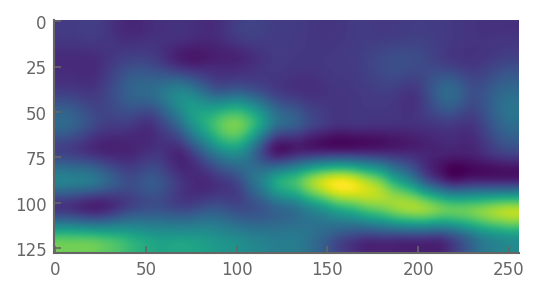

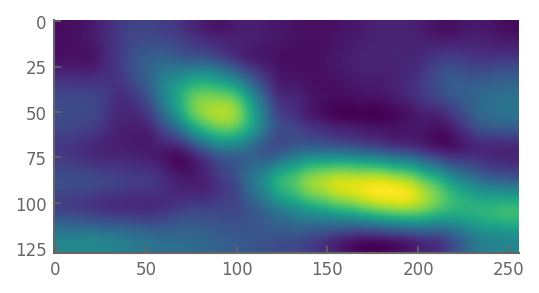

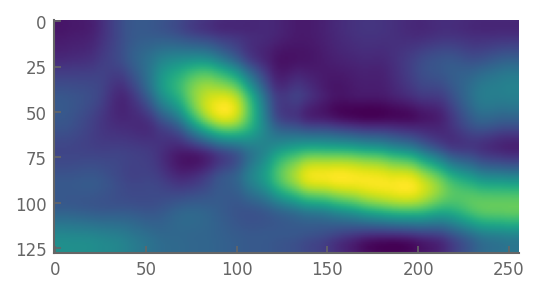

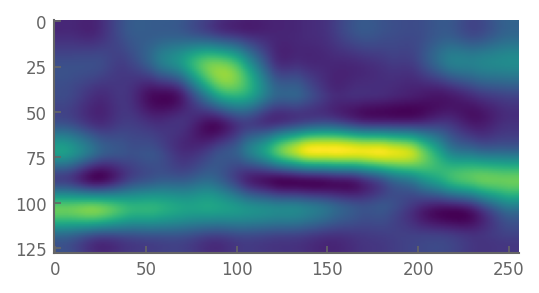

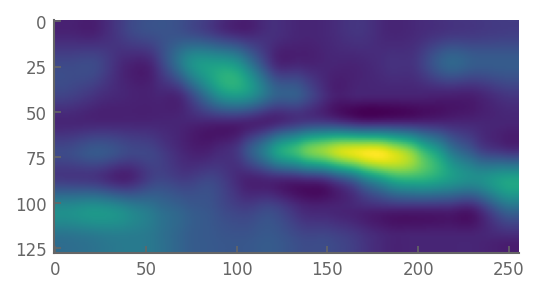

In [53]:
for k in range(8):
    plt.figure()
    plt.imshow(torch.nn.functional.interpolate(out23, scale_factor=16, mode='bicubic')[0][k].detach())

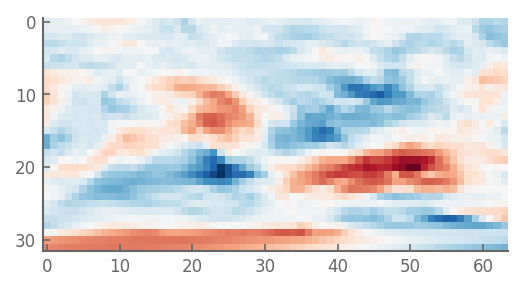

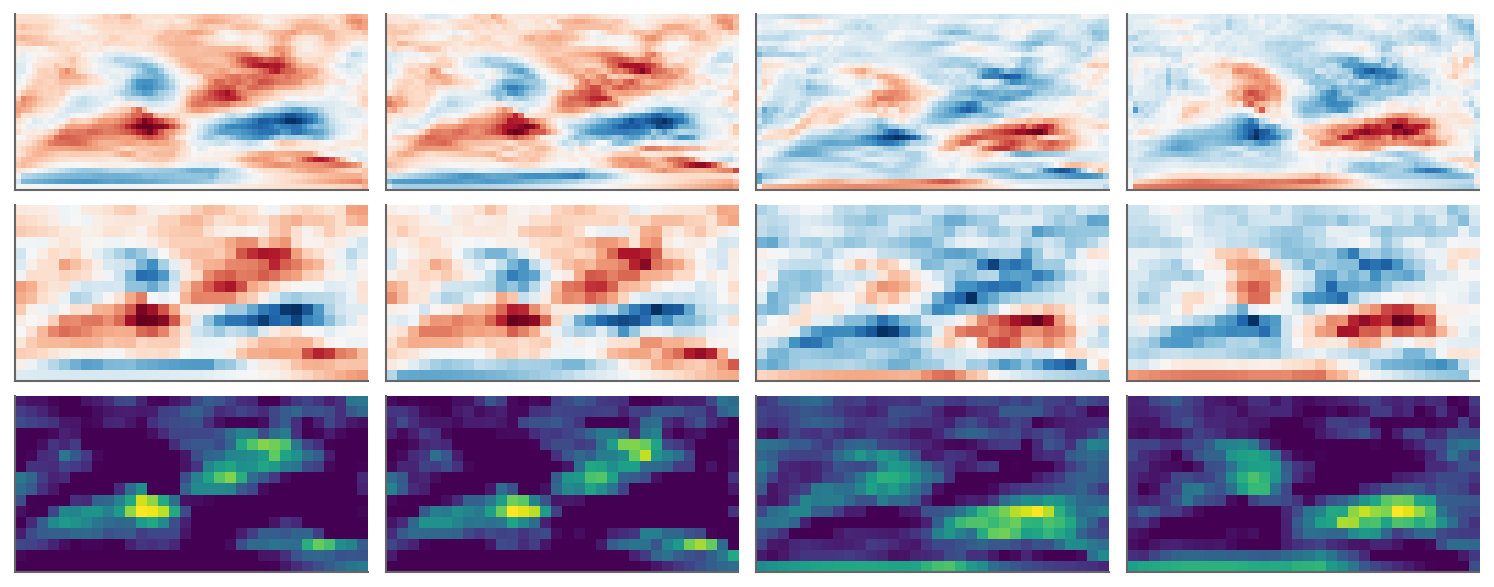

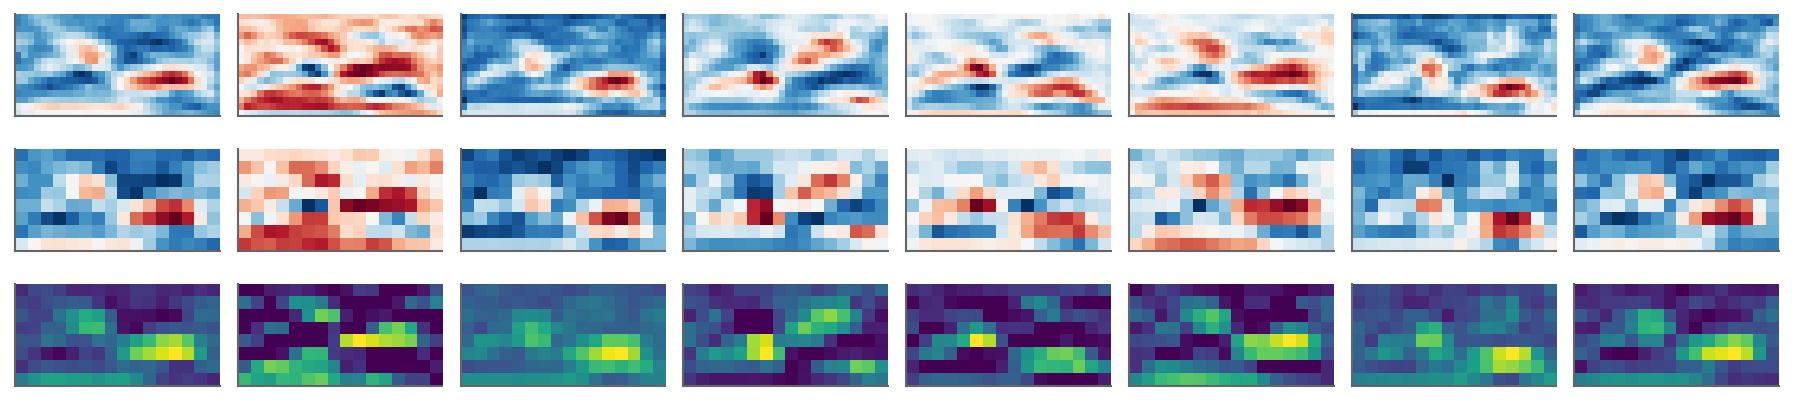

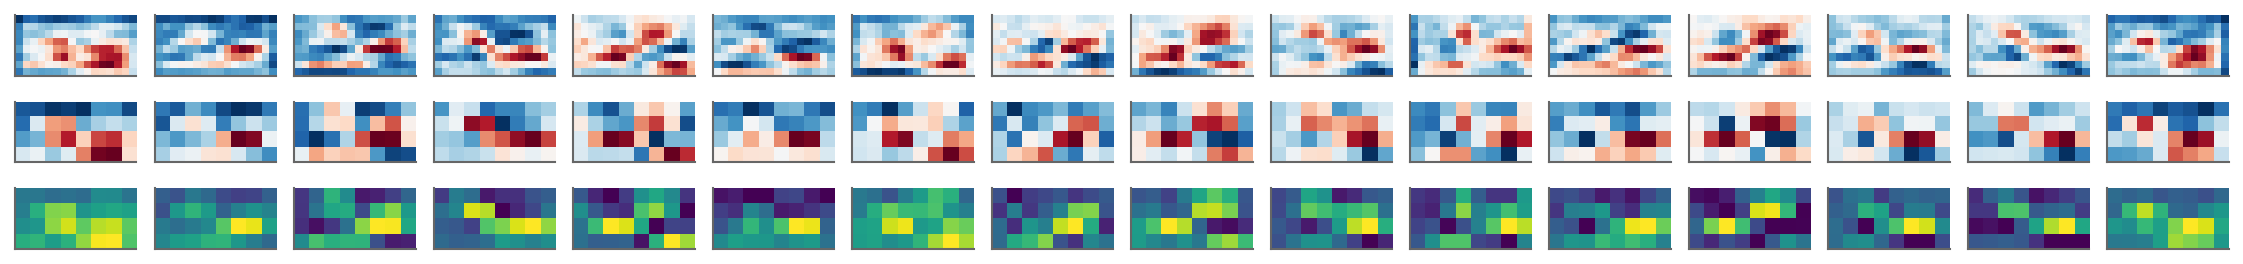

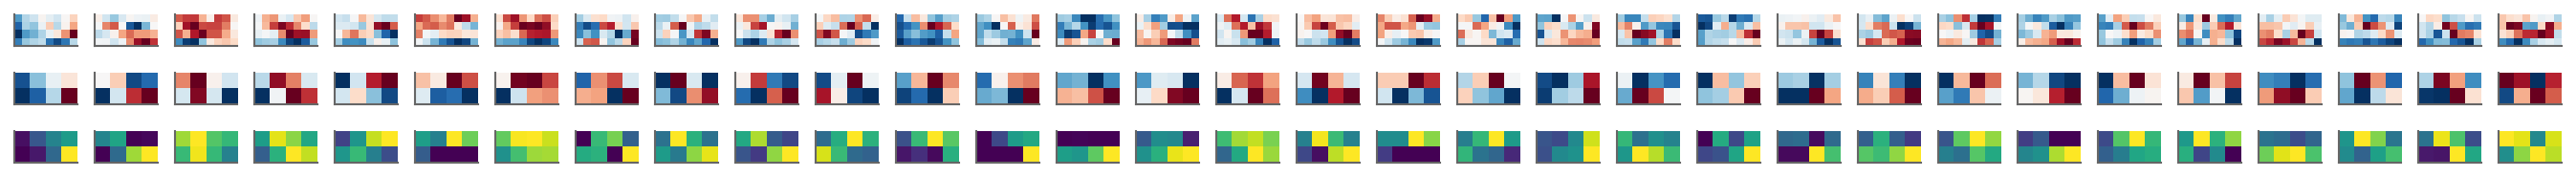

In [14]:
# test = train_loader.dataset[0][0][449]
test = train_loader.dataset[0][0][50]
test.shape

out11 = model.model.conv_layer1[0](test)
out12 = model.model.conv_layer1[1](out11)
out13 = model.model.conv_layer1[2](out12)

out21 = model.model.conv_layer2[0](out13)
out22 = model.model.conv_layer2[1](out21)
out23 = model.model.conv_layer2[2](out22)

out31 = model.model.conv_layer3[0](out23)
out32 = model.model.conv_layer3[1](out31)
out33 = model.model.conv_layer3[2](out32)

out41 = model.model.conv_layer4[0](out33)
out42 = model.model.conv_layer4[1](out41)
out43 = model.model.conv_layer4[2](out42)

fig, ax = plt.subplots()
ax.imshow(test[0], cmap='RdBu_r')

fig, axs = plt.subplots(3,4, figsize=(10,4))
for k in range(4):
    axs[0,k].imshow(out11[k].detach(), cmap='RdBu_r')
    axs[1,k].imshow(out12[k].detach(), cmap='RdBu_r')
    axs[2,k].imshow(out13[k].detach(), cmap='viridis', vmin=0)
for ax in axs.flatten():
    ax.set(title='', yticks=[], xticks=[])
plt.tight_layout()

fig, axs = plt.subplots(3,8, figsize=(12,3))
for k in range(8):
    axs[0,k].imshow(out21[k].detach(), cmap='RdBu_r')
    axs[1,k].imshow(out22[k].detach(), cmap='RdBu_r')
    axs[2,k].imshow(out23[k].detach(),cmap='viridis', vmin=0)
for ax in axs.flatten():
    ax.set(title='', yticks=[], xticks=[])
plt.tight_layout()

fig, axs = plt.subplots(3,16, figsize=(15,2))
for k in range(16):
    axs[0,k].imshow(out31[k].detach(), cmap='RdBu_r')
    axs[1,k].imshow(out32[k].detach(), cmap='RdBu_r')
    axs[2,k].imshow(out33[k].detach(), cmap='viridis', vmin=0)
for ax in axs.flatten():
    ax.set(title='', yticks=[], xticks=[])
plt.tight_layout()

fig, axs = plt.subplots(3,32, figsize=(18,1.5))
for k in range(32):
    axs[0,k].imshow(out41[k].detach(), cmap='RdBu_r')
    axs[1,k].imshow(out42[k].detach(), cmap='RdBu_r')
    axs[2,k].imshow(out43[k].detach(), cmap='viridis', vmin=0)
for ax in axs.flatten():
    ax.set(title='', yticks=[], xticks=[])
plt.tight_layout()


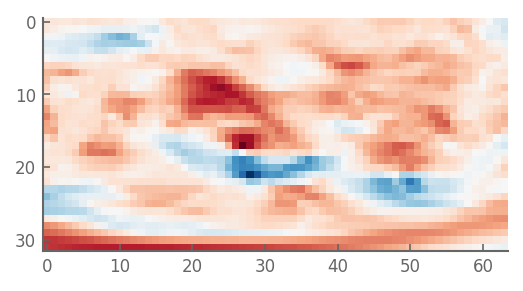

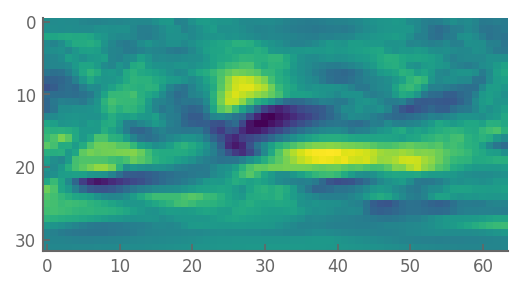

IndexError: index 4 is out of bounds for dimension 0 with size 4

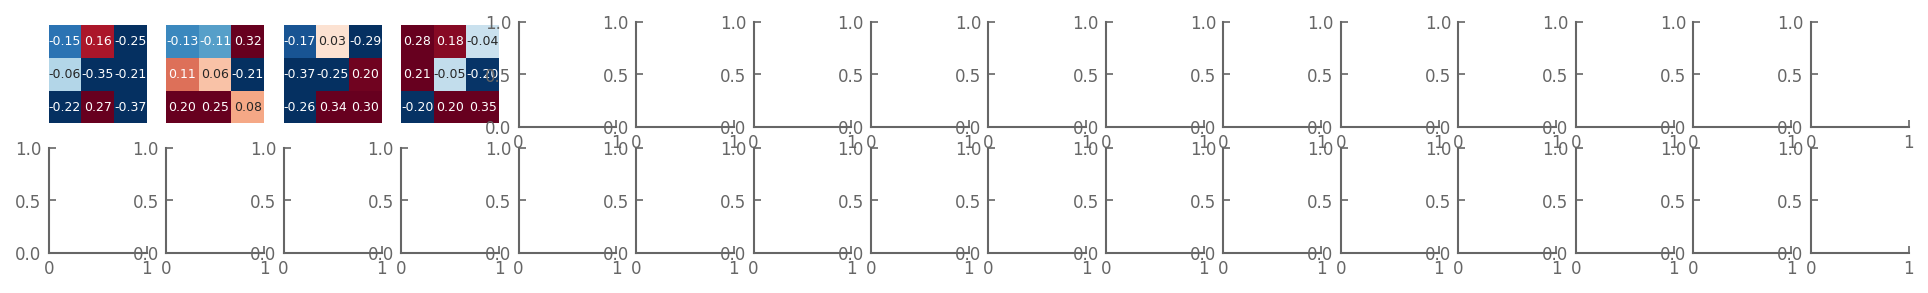

In [61]:
list_weights = []
for k in model.named_parameters():
    list_weights.append(k)
dic_weights = dict(list_weights)
# model.named_parameters()['model.conv_layer1.0.weight']
import itertools
weights_conv1 = dict(list_weights)['model.conv_layer1.0.weight']

fig, axs = plt.subplots(2,16, figsize=(16,2))
for line,row in itertools.product(range(2), range(16)):
    sns.heatmap(pd.DataFrame(weights_conv1[row,line].detach()), square=True, cmap='RdBu_r', vmin=-.2, vmax=.2, cbar=False, ax=axs[line,row], annot=True, fmt='.02f', annot_kws={"size": 6})
    axs[line,row].set(title='',ylabel='',xlabel='', yticks=[], xticks=[])
plt.tight_layout()

In [13]:
for m in model.modules():
    if isinstance(m, nn.Conv2d):
        print(m.weights.data)

AttributeError: 'Conv2d' object has no attribute 'weights'

In [25]:
tensor_in.shape

torch.Size([5, 1, 32, 64])

In [27]:
events_predicted_all.shape

(4092,)

In [116]:
%%time
steps = 4

from captum.attr import IntegratedGradients
method = IntegratedGradients(model.model)
all_multi_attrs = []
all_multi_sens = []

for k in tqdm(range(len(events_predicted))):
    start = start_times[k].strftime("%Y-%m-%d %H:%M:%S")
    end = events_predicted[k].strftime("%Y-%m-%d %H:%M:%S")
    # print(start,end)
    ds_test_extract = ds_test.sel(time=slice(start ,end))
    tensor_in = torch.Tensor(ds_test_extract.inputs.values)
    tensor_out = torch.Tensor(ds_test_extract.targets.values)
    attrs = method.attribute(tensor_in, baselines=torch.Tensor([0]),target=[3*(steps-k)-1 for k in range(steps)]) 
    da_attrs = xr.DataArray(attrs, dims = ['timestep','var_name','latitude','longitude'], 
                            coords= dict(timestep=np.arange(1,steps+1),var_name=ds_test_extract.var_name, latitude=ds_test_extract.latitude, longitude=ds_test_extract.longitude))
    all_multi_attrs.append(da_attrs.assign_coords(time=events_predicted[k]))
    sens = da_attrs/ds_test_extract.inputs.rename(time='timestep').assign_coords(timestep=da_attrs.timestep)
    all_multi_sens.append(sens.assign_coords(time=events_predicted[k]))
ds_attributions = xr.concat(all_multi_attrs, dim='time')
ds_sens = xr.concat(all_multi_sens, dim='time')

  0%|          | 0/114 [00:00<?, ?it/s]

CPU times: user 3min 11s, sys: 188 ms, total: 3min 11s
Wall time: 15.4 s


In [30]:
from matplotlib.path import Path
from matplotlib.patches import PathPatch, Polygon

import cartopy.crs as ccrs
import matplotlib.ticker as mticker
def clean_map(plot, boundaries=(-90, 50, 0, 90)):
    projection = ccrs.LambertConformal(central_longitude=-15.0, central_latitude=39.0)
    lon_min, lon_max , lat_min, lat_max = boundaries
    for ax in plot.axs.flatten():
        ax.coastlines()
        # ax.set_extent((-60,60,0,80))
        ax.set_extent(boundaries, crs=ccrs.PlateCarree())
        
        # ax.set_extent((-60,60,20,80), crs=ccrs.PlateCarree())

        gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=False,
                    linewidth=.5, color='gray', alpha=0.5, linestyle='-')
        gl.xlocator = mticker.FixedLocator(np.linspace(ds_test.longitude.min(),ds_test.longitude.max(),17)[:-1])
        gl.ylocator = mticker.FixedLocator(np.arange(0,81,20))
        
        longitudes = np.linspace(lon_min, lon_max, 100)
        latitudes = np.linspace(lat_min, lat_max,100)
        xx = list(longitudes)[::-1]+\
                [longitudes.min() for _ in range(latitudes.size)] + \
                    list(longitudes)+\
                        [longitudes.max() for _ in range(latitudes.size)]
        yy = [latitudes.max() for _ in range(longitudes.size)] \
                + list(latitudes)[::-1]+\
                    [latitudes.min() for _ in range(longitudes.size)]+ \
                        list(latitudes)[::-1]
        verts = np.array([xx, yy]).T
        circle = Path(verts)
        ax.set_boundary(circle, transform=ccrs.PlateCarree())
        # break
    # ax.set_extent((-60,60,20,80), crs=ccrs.PlateCarree())

def clean_map_nocut(plot):
    projection = ccrs.LambertConformal(central_longitude=-15.0, central_latitude=39.0)
    for ax in plot.axs.flatten():
        ax.coastlines()
        # ax.set_extent((-60,60,0,80))
        # ax.set_extent([-90, 60, 20, 80], crs=ccrs.PlateCarree())
        
        # ax.set_extent((-60,60,20,80), crs=ccrs.PlateCarree())

        gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=False,
                    linewidth=.5, color='gray', alpha=0.5, linestyle='--')
        gl.xlocator = mticker.FixedLocator(np.linspace(ds_test.longitude.min(),ds_test.longitude.max(),17)[:-1])
        gl.ylocator = mticker.FixedLocator(np.arange(20,81,20))
        
        # longitudes = np.linspace(-90, 60, 100)
        # latitudes = np.linspace(20,80,100)
        # xx = list(longitudes)[::-1]+\
        #         [longitudes.min() for _ in range(latitudes.size)] + \
        #             list(longitudes)+\
        #                 [longitudes.max() for _ in range(latitudes.size)]
        # yy = [latitudes.max() for _ in range(longitudes.size)] \
        #         + list(latitudes)[::-1]+\
        #             [latitudes.min() for _ in range(longitudes.size)]+ \
        #                 list(latitudes)[::-1]
        # verts = np.array([xx, yy]).T
        # circle = Path(verts)
        # ax.set_boundary(circle, transform=ccrs.PlateCarree())
        # break
    # ax.set_extent((-60,60,20,80), crs=ccrs.PlateCarree())
    

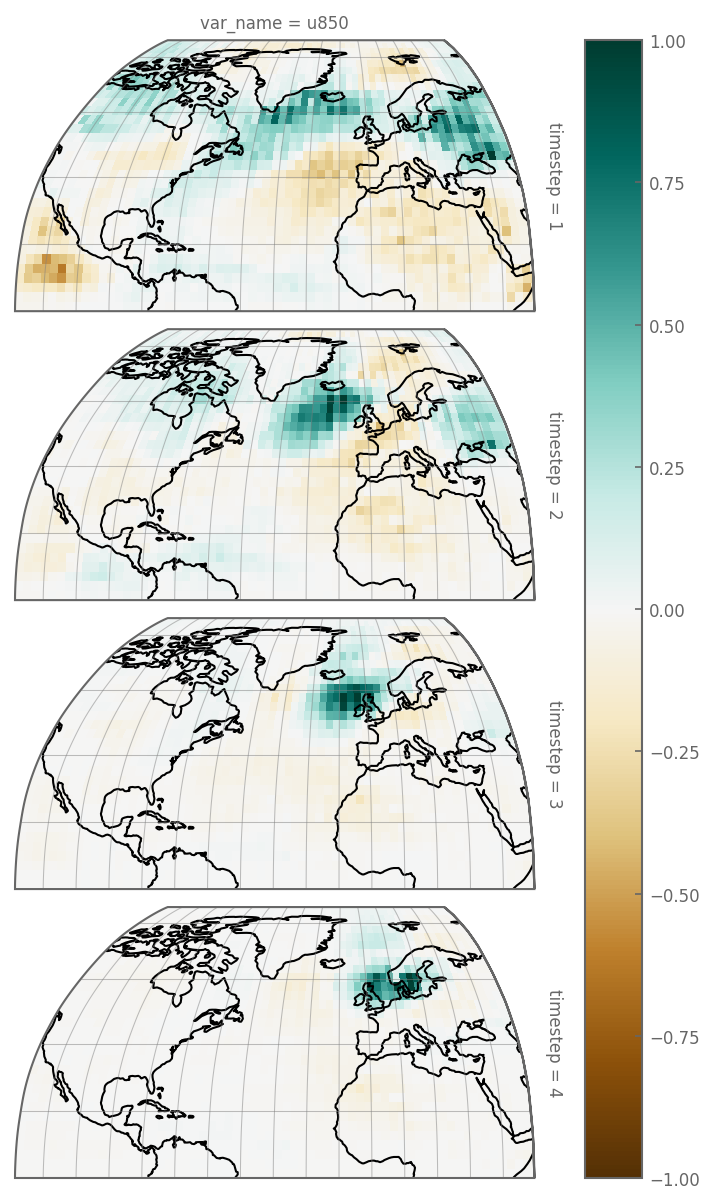

In [14]:

test = ds_attributions.mean('time')#.isel(time=5)#.coarsen(longitude=3,latitude=3,boundary='trim').sum()
test_max = test/test.max(['longitude','latitude', 'var_name'])
projection = ccrs.LambertConformal(central_longitude=-15.0, central_latitude=39.0)
projection = ccrs.Robinson(central_longitude=-15.0)

# test = test.where(test>0.01*test.max(['longitude','latitude','var_name']))
test = test.where(np.abs(test)>1e-3,0)
plot = test_max.plot(row='timestep', col='var_name', subplot_kws = dict(projection=projection), aspect=3, size=2, transform=ccrs.PlateCarree(),
                #  norm = matplotlib.colors.SymLogNorm(linthresh=0.002,linscale=.2), 
                 cmap='BrBG')

clean_map(plot, boundaries = (-125, 50, 0, 90))

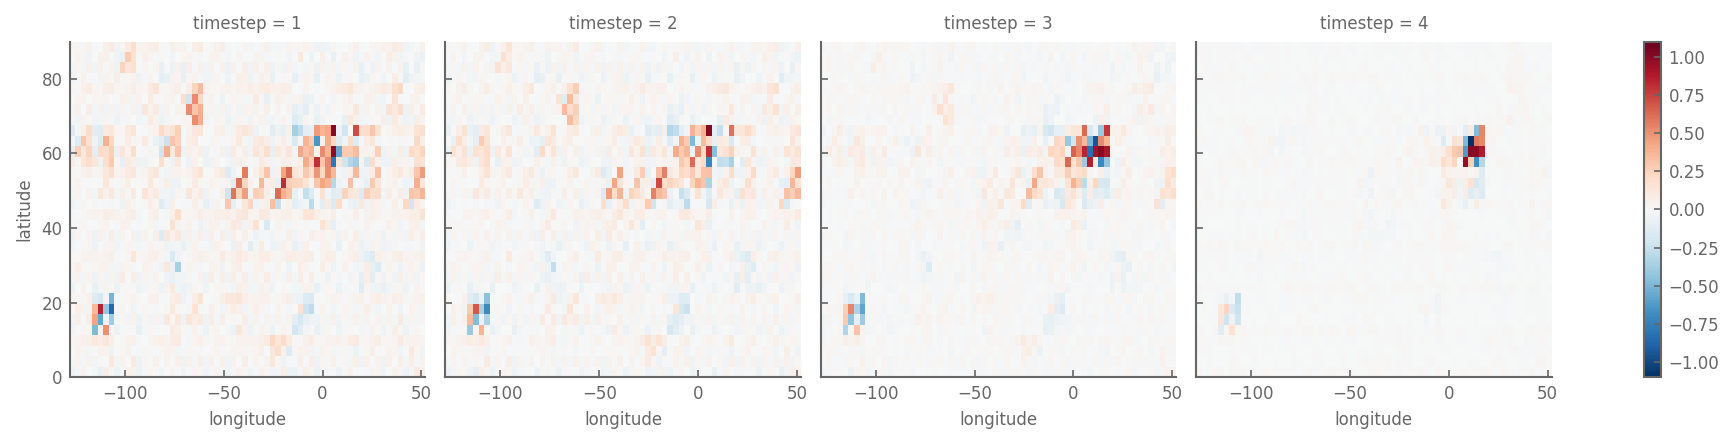

In [17]:
(ds_sens.mean('time')/ds_sens.mean('time').max(['longitude','latitude'])).plot(col='timestep')

In [118]:
final_ds = xr.Dataset(dict(attributions = ds_attributions, sensitivity=ds_sens))
# final_ds = final_ds.rename(time='attribution_time')
final_ds = xr.merge([final_ds, results.assign_coords(timestep=np.arange(1,5))])
n = wandb_logger.experiment.config['num_conv_layer']
# final_ds.to_netcdf(f'out_data/rosendal/u850_{n}conv_layer_attributions.nc')

In [38]:
final_ds.to_netcdf('out_data/rosendal/4conv_layer_all_attributions.nc')
# final_ds.attributions.mean(['longitude','latitude']).plot()

In [20]:
# final_ds.to_netcdf('out_data/rosendal/4conv_layer_linus_style_attributions.nc')
final_ds.to_netcdf('out_data/rosendal/ViT_patch4_attributions.nc')